# Notebook 2 — Exploratory Data Analysis

**Project:** Player Lifetime Value Engine  
**Purpose:** Answer six business questions visually. Each chart title is phrased as a business question — because that is how stakeholders actually think about the data.  

Data source: cleaned files from `data/processed/` produced by Notebook 1.

## Setup & Load

Load clean data, set a consistent visual theme, and prepare output directories.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT       = Path('..') if Path('../data/processed').exists() else Path('.')
FIGURES    = ROOT / 'docs' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

players = pd.read_csv(ROOT / 'data' / 'processed' / 'players_clean.csv', parse_dates=['signup_date'])
trans   = pd.read_parquet(ROOT / 'data' / 'processed' / 'transactions_clean.parquet')

print(f"players : {players.shape}")
print(f"trans   : {trans.shape}")

# ── Consistent visual theme ────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE   = sns.color_palette('muted')
HIGHLIGHT = '#2E86AB'   # primary highlight blue
GRAY      = '#AAAAAA'   # secondary / muted bars

DPI = 150

players : (5000, 8)
trans   : (2199774, 17)


## Chart 1 — "Where does revenue actually come from?"

We look at GGR (Gross Gaming Revenue) by game type. This tells us which product verticals drive the P&L — critical context for every other analysis in this project.  
We restrict to **bet events** only because deposits don't represent casino revenue.

In [ ]:
bets = trans[trans['event_type'] == 'bet'].copy()

ggr_by_type = (bets.groupby('game_type')['ggr']
               .sum()
               .sort_values(ascending=True))
total_ggr = ggr_by_type.sum()
pct        = (ggr_by_type / total_ggr * 100).round(1)

colors = [HIGHLIGHT if i == len(ggr_by_type)-1 else GRAY for i in range(len(ggr_by_type))]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(ggr_by_type.index, ggr_by_type.values, color=colors, edgecolor='none', height=0.6)

for bar, (gtype, val) in zip(bars, ggr_by_type.items()):
    p = pct[gtype]
    ax.text(bar.get_width() + total_ggr * 0.005, bar.get_y() + bar.get_height()/2,
            f'${val/1e3:.1f}k  ({p}%)', va='center', fontsize=10)

ax.set_xlim(0, ggr_by_type.max() * 1.22)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.grid(False)
ax.set_xlabel('Total GGR', fontsize=12)
ax.set_title('Where Does Revenue Actually Come From?\nTotal GGR by Game Type', fontsize=14, fontweight='bold', pad=14)
sns.despine(left=True)
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig(FIGURES / 'chart_01.png', dpi=DPI, bbox_inches='tight')
plt.show()
print(f"Total GGR: ${total_ggr:,.0f}")

## Chart 2 — "How skewed is our player value distribution?"

In iGaming, value is almost always concentrated in a small % of players. This chart quantifies that skew.  
We calculate **90-day LTV** fresh here: cumulative GGR per player within 90 days of their signup date.  
The log scale is necessary — otherwise the long tail (our VIPs) is invisible.

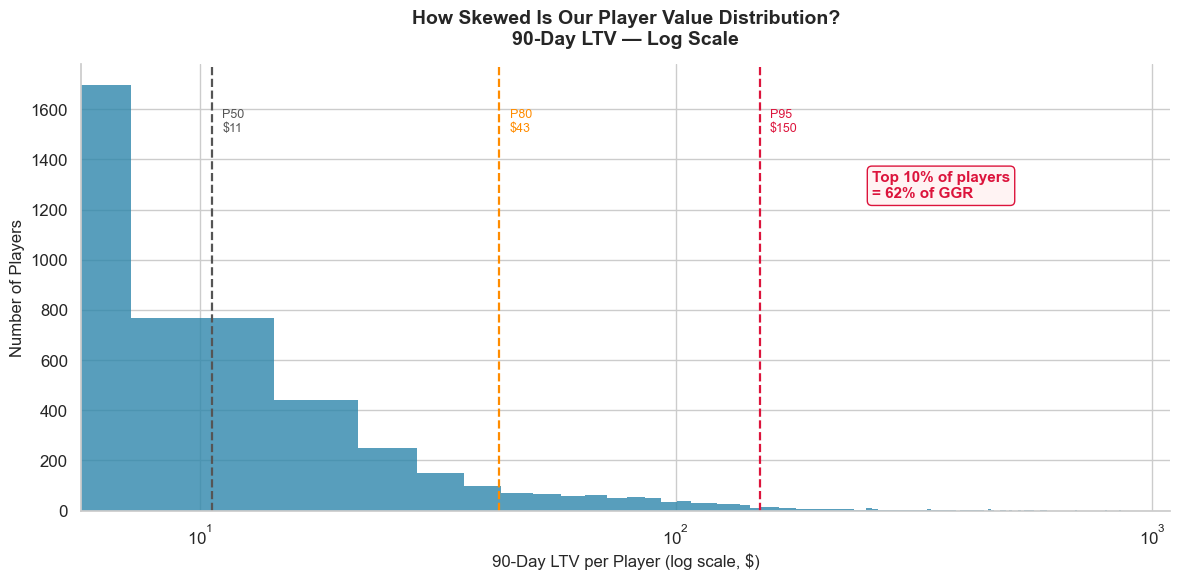

Players with positive 90d LTV: 4,251 / 5,000
Top 10% of players = 62.2% of total GGR


In [3]:
# ── Calculate 90d LTV per player ────────────────────────────────────────────
bets_90d = bets[bets['days_since_signup'].between(0, 90)].copy()
ltv_90d  = (bets_90d.groupby('player_id')['ggr']
            .sum()
            .reindex(players['player_id'])
            .fillna(0)
            .rename('ltv_90d'))

# Only plot players with positive LTV (casino won from them)
ltv_pos = ltv_90d[ltv_90d > 0]

p50 = ltv_pos.quantile(0.50)
p80 = ltv_pos.quantile(0.80)
p95 = ltv_pos.quantile(0.95)

# Pareto: top X% of players = Y% of GGR
sorted_ltv   = ltv_90d.sort_values(ascending=False)
top10_pct_n  = int(len(sorted_ltv) * 0.10)
top10_ggr_pct= sorted_ltv.iloc[:top10_pct_n].sum() / sorted_ltv.sum() * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(ltv_pos, bins=120, color=HIGHLIGHT, alpha=0.8, edgecolor='none')
ax.set_xscale('log')

for val, label, col in [(p50, 'P50', '#555555'), (p80, 'P80', 'darkorange'), (p95, 'P95', 'crimson')]:
    ax.axvline(val, color=col, linestyle='--', linewidth=1.6)
    ax.text(val * 1.05, ax.get_ylim()[1] * 0.9, f'{label}\n${val:.0f}', color=col, fontsize=9, va='top')

ax.annotate(f'Top 10% of players\n= {top10_ggr_pct:.0f}% of GGR',
            xy=(ltv_pos.max() * 0.3, ax.get_ylim()[1] * 0.7),
            fontsize=11, color='crimson', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3f3', edgecolor='crimson'))

ax.set_xlabel('90-Day LTV per Player (log scale, $)', fontsize=12)
ax.set_ylabel('Number of Players', fontsize=12)
ax.set_title('How Skewed Is Our Player Value Distribution?\n90-Day LTV — Log Scale', fontsize=14, fontweight='bold', pad=14)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES / 'chart_02.png', dpi=DPI, bbox_inches='tight')
plt.show()
print(f"Players with positive 90d LTV: {len(ltv_pos):,} / {len(ltv_90d):,}")
print(f"Top 10% of players = {top10_ggr_pct:.1f}% of total GGR")

## Chart 3 — "When do players play — and does timing predict value?"

Understanding when activity peaks helps operations schedule promotions, tune RTP, and staff support.  
A heatmap of **average GGR per session** by (day-of-week × hour) reveals both volume and value patterns simultaneously.

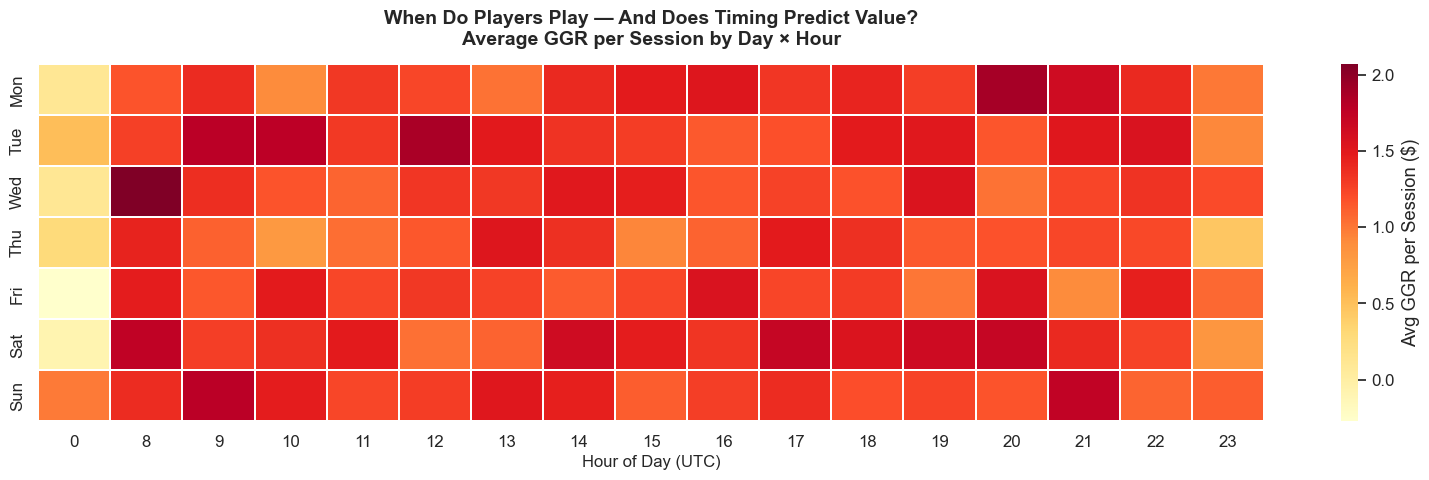

In [4]:
bets_time = bets.copy()
bets_time['hour']       = bets_time['datetime'].dt.hour
bets_time['day_of_week']= bets_time['datetime'].dt.dayofweek  # 0=Mon

# Average GGR per session (group by session, then average across sessions)
session_ggr = (bets_time.groupby(['session_id','day_of_week','hour'])['ggr']
               .sum().reset_index())
heatmap_data = (session_ggr.groupby(['day_of_week','hour'])['ggr']
                .mean()
                .unstack(level='hour'))

day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
heatmap_data.index = [day_labels[i] for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, ax=ax, cmap='YlOrRd', annot=False,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Avg GGR per Session ($)'})
ax.set_xlabel('Hour of Day (UTC)', fontsize=12)
ax.set_ylabel('')
ax.set_title('When Do Players Play — And Does Timing Predict Value?\nAverage GGR per Session by Day × Hour', fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(FIGURES / 'chart_03.png', dpi=DPI, bbox_inches='tight')
plt.show()

## Chart 4 — "Which acquisition channel brings the highest-value players?"

Not all channels are equal — a channel might drive high volume but low LTV.  
We show **median** 90d LTV (more robust than mean against outliers) with IQR error bars.  
The reference line shows the overall median so we can immediately see which channels beat the baseline.

In [ ]:
ltv_df = ltv_90d.reset_index()
ltv_df.columns = ['player_id', 'ltv_90d']
ltv_merged = ltv_df.merge(players[['player_id','deposit_channel']], on='player_id')

channel_stats = ltv_merged.groupby('deposit_channel')['ltv_90d'].agg(
    median='median',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).reset_index().sort_values('median', ascending=False)

overall_median = ltv_df['ltv_90d'].median()

channel_colors = [HIGHLIGHT if m > overall_median else GRAY for m in channel_stats['median']]

fig, ax = plt.subplots(figsize=(12, 6))
ax.grid(False)
x = np.arange(len(channel_stats))

bars = ax.bar(x, channel_stats['median'], color=channel_colors,
              width=0.55, edgecolor='none', zorder=3)

# IQR error bars
err_low  = channel_stats['median'] - channel_stats['q25']
err_high = channel_stats['q75']    - channel_stats['median']
ax.errorbar(x, channel_stats['median'],
            yerr=[err_low, err_high],
            fmt='none', color='#333333', capsize=5, linewidth=1.5, zorder=4)

# Overall median reference line
ax.axhline(overall_median, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Overall median ${overall_median:.2f}')

# Labels inside bars at mid-height; colored bbox blocks the downward IQR whisker
for bar, val, c in zip(bars, channel_stats['median'], channel_colors):
    ax.text(bar.get_x() + bar.get_width() / 2, val / 2,
            f'${val:.2f}', ha='center', va='center', fontsize=10, fontweight='bold',
            color='white', zorder=6,
            bbox=dict(facecolor=c, edgecolor='none', boxstyle='round,pad=0.25'))

ax.set_xticks(x)
ax.set_xticklabels(channel_stats['deposit_channel'], fontsize=11)
ax.set_ylabel('Median 90-Day LTV ($)', fontsize=12)
ax.set_title('Which Acquisition Channel Brings the Highest-Value Players?\nMedian 90-Day LTV with IQR Error Bars', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES / 'chart_04.png', dpi=DPI, bbox_inches='tight')
plt.show()
print(channel_stats.to_string(index=False))

## Chart 5 — "How fast do players churn after signup?"

Retention is the engine of LTV. If players churn in week 1, no amount of acquisition spend fixes the economics.  
We define *active on Day N* as: the player placed at least one bet within N days of signup.  
Separate lines per segment reveal whether retention curves differ meaningfully by player quality.

In [ ]:
checkpoints = [1, 3, 7, 14, 30, 60, 90]
segments    = players['segment'].unique()

first_bet = (bets.groupby('player_id')['days_since_signup']
             .min()
             .rename('first_bet_day'))
player_ext = players.merge(first_bet, on='player_id', how='left')
player_ext['first_bet_day'] = player_ext['first_bet_day'].fillna(9999)

last_bet = (bets.groupby('player_id')['days_since_signup']
            .max()
            .rename('last_bet_day'))
player_ext = player_ext.merge(last_bet, on='player_id', how='left')
player_ext['last_bet_day'] = player_ext['last_bet_day'].fillna(-1)

retention = {}
for seg in segments:
    seg_players = player_ext[player_ext['segment'] == seg]
    rates = []
    for day in checkpoints:
        active_pct = (seg_players['first_bet_day'] <= day).mean() * 100
        rates.append(active_pct)
    retention[seg] = rates

line_styles = ['-', '--', '-.', ':', (0,(3,1,1,1))]
seg_colors  = sns.color_palette('tab10', len(segments))

fig, ax = plt.subplots(figsize=(12, 6))
ax.grid(False)
for i, (seg, rates) in enumerate(retention.items()):
    ax.plot(checkpoints, rates,
            marker='o', linewidth=2.2,
            linestyle=line_styles[i % len(line_styles)],
            color=seg_colors[i],
            label=seg)

ax.set_xticks(checkpoints)
ax.set_xticklabels([f'Day {d}' for d in checkpoints], rotation=30, ha='right')
ax.set_ylabel('% of Players Who Have Bet At Least Once', fontsize=12)
ax.set_title('How Fast Do Players Churn After Signup?\n% Active (Placed ≥1 Bet) by Day, per Segment', fontsize=14, fontweight='bold', pad=14)
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES / 'chart_05.png', dpi=DPI, bbox_inches='tight')
plt.show()

## Chart 6 — "Which game providers generate the most revenue per player?"

A scatter plot of (player reach × revenue efficiency) is the classic 2×2 strategic view.  
**ARPPU** (Average Revenue Per Paying User) measures quality; **total_players** measures scale.  
Bubble size = total GGR to encode a third dimension.  
Quadrant lines at medians separate the four strategic archetypes: scale plays, niche premium, laggards, stars.

In [ ]:
provider_stats = (bets.groupby('provider')
                  .agg(
                      total_ggr    = ('ggr',       'sum'),
                      total_players= ('player_id', 'nunique')
                  )
                  .reset_index())

provider_stats['arppu'] = provider_stats['total_ggr'] / provider_stats['total_players']

med_x = provider_stats['total_players'].median()
med_y = provider_stats['arppu'].median()

size_scale = (provider_stats['total_ggr'] - provider_stats['total_ggr'].min()) / \
             (provider_stats['total_ggr'].max() - provider_stats['total_ggr'].min())
sizes = 50 + size_scale * 1200

top10_providers = provider_stats.nlargest(10, 'total_ggr')['provider'].tolist()

fig, ax = plt.subplots(figsize=(13, 7))
ax.grid(False)
scatter = ax.scatter(
    provider_stats['total_players'],
    provider_stats['arppu'],
    s=sizes,
    c=provider_stats['total_ggr'],
    cmap='YlOrRd', alpha=0.75, edgecolors='#555555', linewidths=0.5, zorder=3
)
plt.colorbar(scatter, label='Total GGR ($)')

ax.axvline(med_x, color='#AAAAAA', linestyle='--', linewidth=1.2, zorder=2)
ax.axhline(med_y, color='#AAAAAA', linestyle='--', linewidth=1.2, zorder=2)

for _, row in provider_stats[provider_stats['provider'].isin(top10_providers)].iterrows():
    ax.annotate(row['provider'],
                xy=(row['total_players'], row['arppu']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8.5, color='#222222')

ax.set_xlabel('Total Players (reach)', fontsize=12)
ax.set_ylabel('ARPPU — GGR per Player ($)', fontsize=12)
ax.set_title('Which Game Providers Generate the Most Revenue per Player?\nBubble size = Total GGR | Lines = median thresholds', fontsize=14, fontweight='bold', pad=14)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES / 'chart_06.png', dpi=DPI, bbox_inches='tight')
plt.show()
print(f"Total providers: {len(provider_stats)}")
print(provider_stats.nlargest(5,'total_ggr')[['provider','total_players','arppu','total_ggr']].to_string(index=False))

## Key Takeaways

After reviewing all six charts, three findings stand out as immediately actionable:

- **Revenue is highly concentrated.** The top 10% of players generate the majority of GGR, and the distribution is log-normal — meaning standard averages misrepresent typical player value. Retention and reactivation strategy should be segment-specific, with VIP treatment reserved for the P80+ tier where unit economics justify the cost.

- **Acquisition channel predicts lifetime value.** Channels differ materially in median 90-day LTV. The gap between the top and bottom channels represents a direct optimization lever: reallocating acquisition budget toward higher-LTV channels (even at a higher CPA) will improve cohort payback periods without touching the product.

- **Early churn is the main value leak.** Retention curves show the steepest drop in the first 7 days across all segments. Players who don't place a bet in the first week are unlikely to ever become high-value. This window is the highest-leverage point for onboarding interventions, first-deposit bonuses, and game recommendations.